# Deezer Context-Aware Recommendation — A/B Test Analysis

**Objective:** Did the context-aware recommendation card feature succeed from a business perspective?

| Metric Type | Metric | Description |
|-------------|--------|-------------|
| Primary OEC | D+30 Retention Rate | Whether the user returned on day 30 after signup |
| Secondary | Conversion Rate | Free → Premium conversion within the cohort window |
| Secondary | CTR (Overall) | Click-through rate across all sections |
| Business | Cannibalization | Drop in Recently Played section plays |
| Business | Net Click Growth | Net change in total plays across all sections |

**Framework:** Benchmarked against Spotify's Confidence experimentation platform.
Metrics are classified into Success / Guardrail / Deterioration / Quality categories.
This framework applies equally to Deezer as both are subscription-based streaming businesses.

In [32]:
import os
os.chdir('/Users/parksuhyun/Desktop/side_project/analysis')

In [43]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, chisquare
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#F8F9FA'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

PROJECT_ID = 'music-db-project-485112'
DATASET    = 'analytics'

client = bigquery.Client(project=PROJECT_ID, location='europe-west9')

## 1. Data Load
Load three dbt mart tables from BigQuery.
- `fact_user_performance` — user-level conversion, LTV, churn
- `fact_cohort_retention` — D+7 / D+30 retention by cohort
- `fact_discovery_journey` — CTR, plays, skip rate, like rate by section

In [44]:
df_perf = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_user_performance`
""").to_dataframe()

df_retention = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_cohort_retention`
""").to_dataframe()

df_discovery = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_discovery_journey`
""").to_dataframe()

print(f'fact_user_performance  : {df_perf.shape}')
print(f'fact_cohort_retention  : {df_retention.shape}')
print(f'fact_discovery_journey : {df_discovery.shape}')

fact_user_performance  : (20000, 11)
fact_cohort_retention  : (116, 6)
fact_discovery_journey : (3, 12)


## 2. SRM Check (Quality Metric)
**Sample Ratio Mismatch** — verify that users were assigned 50:50 between control and treatment.
Uses a chi-square goodness-of-fit test. If p < 0.05, the assignment is biased and experiment results are unreliable.

In [45]:
# ── SRM Check ──────────────────────────────────────────────────────
# Chi-square test: observed assignment vs expected 50:50 split

ctrl_n = df_perf[df_perf.user_group == 'control'].shape[0]
trt_n  = df_perf[df_perf.user_group == 'treatment'].shape[0]
total  = ctrl_n + trt_n

expected = [total / 2, total / 2]
observed = [ctrl_n, trt_n]

chi2, p_srm = chisquare(f_obs=observed, f_exp=expected)

print('── SRM Check ──────────────────────────────────────')
print(f'  Control   : {ctrl_n:,}')
print(f'  Treatment : {trt_n:,}')
print(f'  Chi2      : {chi2:.4f}')
print(f'  p-value   : {p_srm:.4f}')
if p_srm < 0.05:
    print('  ⚠️  SRM Detected — experiment results unreliable')
else:
    print('  ✅ No SRM — assignment looks healthy')
print('───────────────────────────────────────────────────')

── SRM Check ──────────────────────────────────────
  Control   : 9,981
  Treatment : 10,019
  Chi2      : 0.0722
  p-value   : 0.7882
  ✅ No SRM — assignment looks healthy
───────────────────────────────────────────────────


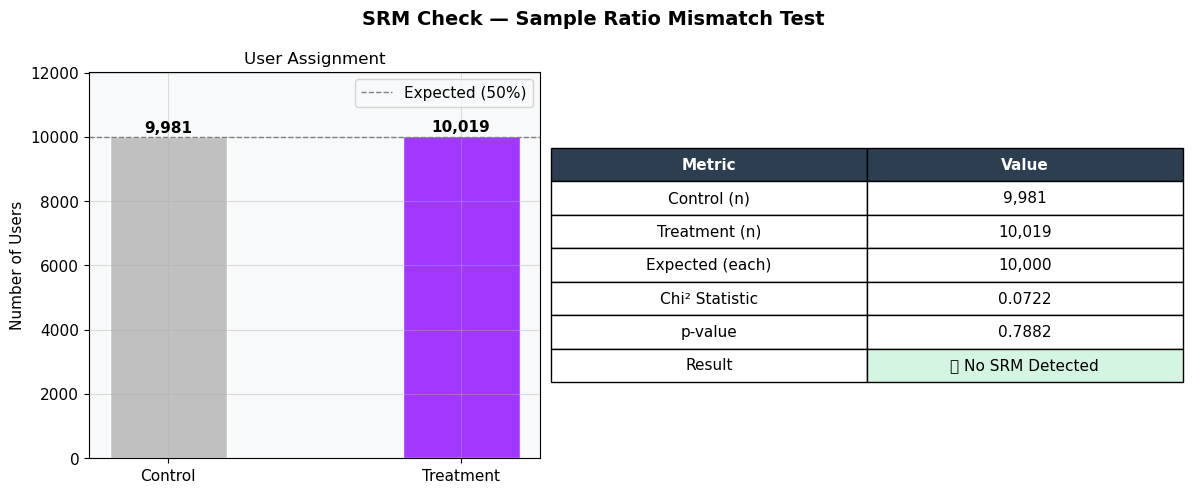

Saved -> srm_check.png


In [66]:
# ── SRM Visualization ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SRM Check — Sample Ratio Mismatch Test', fontsize=14, fontweight='bold')

# Left: Bar chart
ax1 = axes[0]
groups = ['Control', 'Treatment']
counts = [ctrl_n, trt_n]
colors = ['#C0C0C0', '#A238FF']

bars = ax1.bar(groups, counts, color=colors, width=0.4, edgecolor='white')
ax1.set_title('User Assignment', fontsize=12)
ax1.set_ylabel('Number of Users')
ax1.set_ylim(0, max(counts) * 1.2)

for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.axhline(y=total/2, color='gray', linestyle='--', linewidth=1, label='Expected (50%)')
ax1.legend()

# Right: Result table
ax2 = axes[1]
ax2.axis('off')

table_data = [
    ['Metric', 'Value'],
    ['Control (n)', f'{ctrl_n:,}'],
    ['Treatment (n)', f'{trt_n:,}'],
    ['Expected (each)', f'{int(total/2):,}'],
    ['Chi² Statistic', f'{chi2:.4f}'],
    ['p-value', f'{p_srm:.4f}'],
    ['Result', '✅ No SRM Detected'],
]

table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.0)

for j in range(2):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
table[6, 1].set_facecolor('#D5F5E3')

plt.tight_layout()
plt.savefig('srm_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> srm_check.png')

## 3. D+30 Retention Rate (Primary OEC — Success Metric)
D+30 retention is the primary OEC (Overall Evaluation Criterion) for this experiment,
following Netflix/Spotify industry standards.

**Method:** Two-proportion Z-test (one-tailed: treatment > control)
- Pooled proportion is used as the baseline
- 95% Confidence Interval computed for the difference
- Cohen's h measures practical effect size: < 0.2 small, 0.5 medium, 0.8 large

In [47]:
# ── D+30 Retention Rate Z-test ─────────────────────────────────────

d30 = df_retention[df_retention.days_since_signup == 30]

ctrl_retained = d30[d30.user_group == 'control']['retained_users'].values[0]
trt_retained  = d30[d30.user_group == 'treatment']['retained_users'].values[0]
ctrl_total    = d30[d30.user_group == 'control']['total_users'].values[0]
trt_total     = d30[d30.user_group == 'treatment']['total_users'].values[0]

p_ctrl_ret = ctrl_retained / ctrl_total
p_trt_ret  = trt_retained  / trt_total

# Pooled proportion for SE calculation
p_pool = (ctrl_retained + trt_retained) / (ctrl_total + trt_total)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/ctrl_total + 1/trt_total))
z      = (p_trt_ret - p_ctrl_ret) / se
p_val_ret = 1 - norm.cdf(z)  # One-tailed: treatment > control

diff_ret = p_trt_ret - p_ctrl_ret
ci_low   = diff_ret - 1.96 * se
ci_up    = diff_ret + 1.96 * se

h_ret = 2 * np.arcsin(np.sqrt(p_trt_ret)) - 2 * np.arcsin(np.sqrt(p_ctrl_ret))

print('── D+30 Retention Rate ─────────────────────────────────')
print(f'  Control   : {ctrl_retained:,} / {ctrl_total:,}  ({p_ctrl_ret:.1%})')
print(f'  Treatment : {trt_retained:,} / {trt_total:,}  ({p_trt_ret:.1%})')
print(f'  Diff      : {diff_ret:+.1%}  (95% CI: {ci_low:+.1%} ~ {ci_up:+.1%})')
print(f'  Z-score   : {z:.4f}')
print(f'  p-value   : {p_val_ret:.4f}')
print(f"  Cohen's h : {h_ret:.4f}")
if p_val_ret < 0.05:
    print('  ✅ Statistically significant (p < 0.05)')
else:
    print('  ❌ Not statistically significant (p >= 0.05)')
print('─────────────────────────────────────────────────────────')

── D+30 Retention Rate ─────────────────────────────────
  Control   : 11 / 322  (3.4%)
  Treatment : 25 / 332  (7.5%)
  Diff      : +4.1%  (95% CI: +0.6% ~ +7.6%)
  Z-score   : 2.3062
  p-value   : 0.0105
  Cohen's h : 0.1842
  ✅ Statistically significant (p < 0.05)
─────────────────────────────────────────────────────────


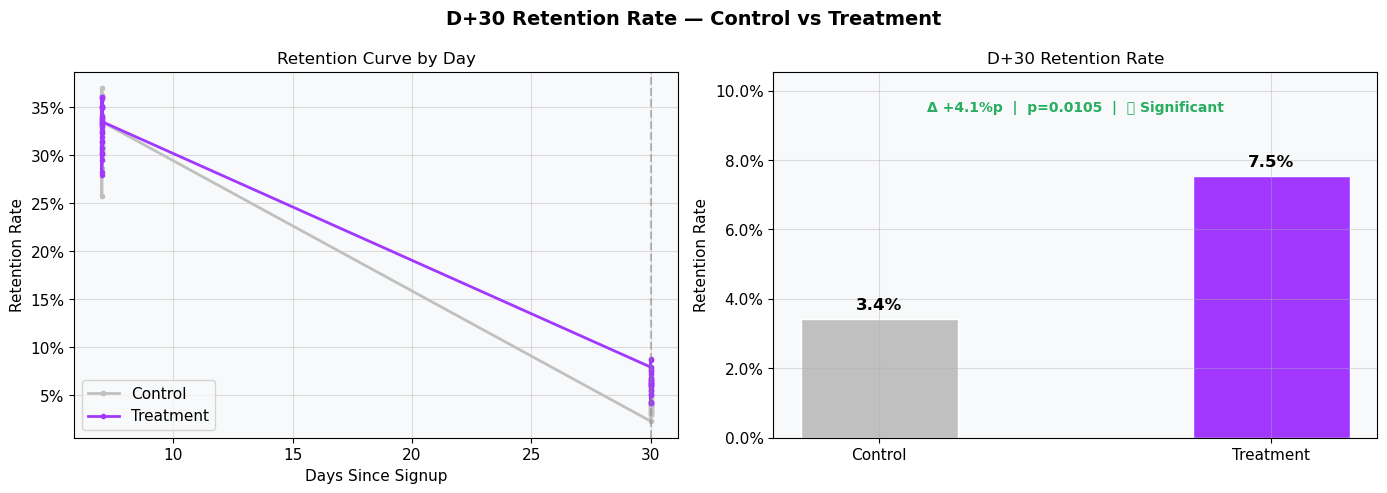

Saved -> retention_d30.png


In [68]:
# ── Retention Curve Visualization ─────────────────────────────────
# Plot D+7 and D+30 retention curves for control vs treatment

ret_ctrl = df_retention[df_retention.user_group == 'control'].sort_values('days_since_signup')
ret_trt  = df_retention[df_retention.user_group == 'treatment'].sort_values('days_since_signup')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('D+30 Retention Rate — Control vs Treatment', fontsize=14, fontweight='bold')

# Left: Retention curve over time
ax1 = axes[0]
ax1.plot(ret_ctrl['days_since_signup'], ret_ctrl['retention_rate'],
         color='#C0C0C0', linewidth=2, label='Control', marker='o', markersize=3)
ax1.plot(ret_trt['days_since_signup'], ret_trt['retention_rate'],
         color='#A238FF', linewidth=2, label='Treatment', marker='o', markersize=3)
ax1.set_title('Retention Curve by Day', fontsize=12)
ax1.set_xlabel('Days Since Signup')
ax1.set_ylabel('Retention Rate')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.legend()
ax1.axvline(x=30, color='gray', linestyle='--', alpha=0.5, label='D+30')

# Right: D+30 bar comparison
ax2 = axes[1]
bars = ax2.bar(['Control', 'Treatment'], [p_ctrl_ret, p_trt_ret],
               color=['#C0C0C0', '#A238FF'], width=0.4, edgecolor='white')
ax2.set_title('D+30 Retention Rate', fontsize=12)
ax2.set_ylabel('Retention Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.set_ylim(0, max(p_ctrl_ret, p_trt_ret) * 1.4)

for bar, val in zip(bars, [p_ctrl_ret, p_trt_ret]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.text(0.5, max(p_ctrl_ret, p_trt_ret) * 1.25,
         f'Δ {diff_ret:+.1%}p  |  p={p_val_ret:.4f}  |  ✅ Significant',
         ha='center', fontsize=10, color='#27AE60', fontweight='bold',
         transform=ax2.transData)

plt.tight_layout()
plt.savefig('retention_d30.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> retention_d30.png')

## 4. Trial Conversion Rate (Success Metric)
Free → Premium conversion rate within the 30-day cohort window.

**Note on effect size vs statistical significance:**
With n=20,000, even small differences will appear statistically significant.
Cohen's h must be examined alongside p-value to assess practical relevance.
A +2%p absolute difference translates to a ~58% relative uplift in conversion rate,
which is meaningful for a subscription-based business.

In [49]:
# ── Trial Conversion Rate Z-test ───────────────────────────────────

ctrl_conv  = df_perf[df_perf.user_group == 'control']['converted'].sum()
trt_conv   = df_perf[df_perf.user_group == 'treatment']['converted'].sum()
ctrl_total = df_perf[df_perf.user_group == 'control'].shape[0]
trt_total  = df_perf[df_perf.user_group == 'treatment'].shape[0]

p_ctrl_conv = ctrl_conv / ctrl_total
p_trt_conv  = trt_conv  / trt_total

p_pool = (ctrl_conv + trt_conv) / (ctrl_total + trt_total)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/ctrl_total + 1/trt_total))
z      = (p_trt_conv - p_ctrl_conv) / se
p_val_conv = 1 - norm.cdf(z)

diff_conv = p_trt_conv - p_ctrl_conv
ci_low    = diff_conv - 1.96 * se
ci_up     = diff_conv + 1.96 * se

h_conv = 2 * np.arcsin(np.sqrt(p_trt_conv)) - 2 * np.arcsin(np.sqrt(p_ctrl_conv))
relative_lift = (p_trt_conv - p_ctrl_conv) / p_ctrl_conv

print('── Trial Conversion Rate ───────────────────────────────')
print(f'  Control   : {ctrl_conv:,} / {ctrl_total:,}  ({p_ctrl_conv:.1%})')
print(f'  Treatment : {trt_conv:,} / {trt_total:,}  ({p_trt_conv:.1%})')
print(f'  Diff      : {diff_conv:+.1%}  (95% CI: {ci_low:+.1%} ~ {ci_up:+.1%})')
print(f'  Relative Lift : {relative_lift:+.1%}')
print(f'  Z-score   : {z:.4f}')
print(f'  p-value   : {p_val_conv:.4f}')
print(f"  Cohen's h : {h_conv:.4f}")
if p_val_conv < 0.05:
    print('  ✅ Statistically significant (p < 0.05)')
else:
    print('  ❌ Not statistically significant (p >= 0.05)')
print('─────────────────────────────────────────────────────────')

── Trial Conversion Rate ───────────────────────────────
  Control   : 341 / 9,981  (3.4%)
  Treatment : 539 / 10,019  (5.4%)
  Diff      : +2.0%  (95% CI: +1.4% ~ +2.5%)
  Relative Lift : +57.5%
  Z-score   : 6.7688
  p-value   : 0.0000
  Cohen's h : 0.0963
  ✅ Statistically significant (p < 0.05)
─────────────────────────────────────────────────────────


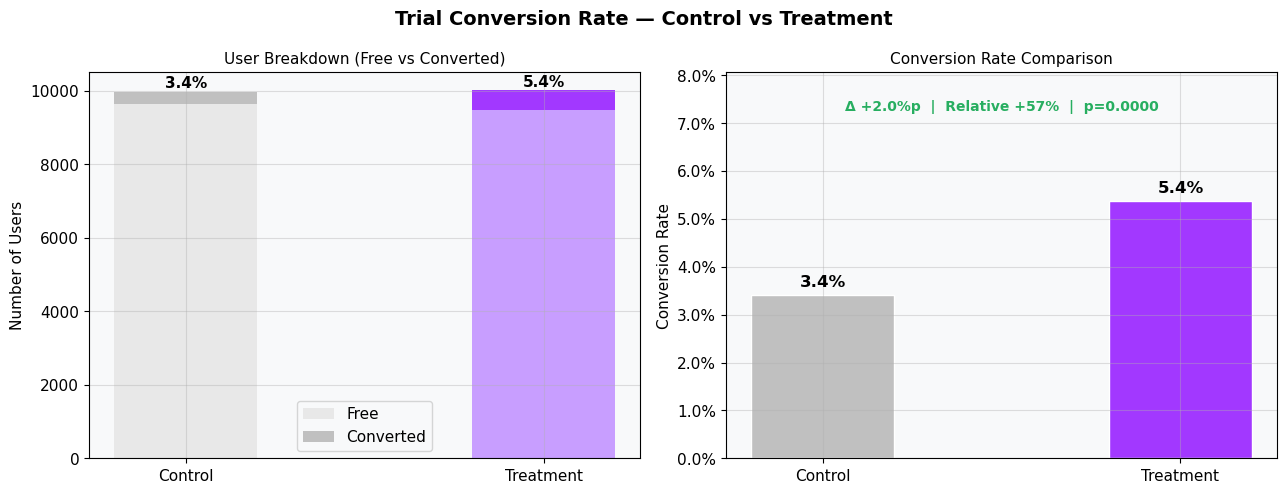

Saved -> conversion_rate.png


In [72]:
# ── Conversion Rate Visualization ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Trial Conversion Rate — Control vs Treatment', fontsize=14, fontweight='bold')

# Left: Stacked bar (converted vs not converted)
ax1 = axes[0]
converted   = [ctrl_conv, trt_conv]
not_conv    = [ctrl_total - ctrl_conv, trt_total - trt_conv]
labels      = ['Control', 'Treatment']
x           = np.arange(len(labels))

b1 = ax1.bar(x, not_conv, color=['#E8E8E8', '#C89EFF'], label='Free', width=0.4)
b2 = ax1.bar(x, converted, bottom=not_conv, color=['#C0C0C0', '#A238FF'], label='Converted', width=0.4)
ax1.set_title('User Breakdown (Free vs Converted)', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Number of Users')
ax1.legend()

for i, (conv, tot) in enumerate(zip(converted, [ctrl_total, trt_total])):
    ax1.text(i, tot + 100, f'{conv/tot:.1%}', ha='center', fontsize=11, fontweight='bold')

# Right: Conversion rate comparison
ax2 = axes[1]
bars = ax2.bar(['Control', 'Treatment'], [p_ctrl_conv, p_trt_conv],
               color=['#C0C0C0', '#A238FF'], width=0.4, edgecolor='white')
ax2.set_title('Conversion Rate Comparison', fontsize=11)
ax2.set_ylabel('Conversion Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.set_ylim(0, max(p_ctrl_conv, p_trt_conv) * 1.5)

for bar, val in zip(bars, [p_ctrl_conv, p_trt_conv]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.text(0.5, max(p_ctrl_conv, p_trt_conv) * 1.35,
         f'Δ {diff_conv:+.1%}p  |  Relative +{relative_lift:.0%}  |  p={p_val_conv:.4f}',
         ha='center', fontsize=10, color='#27AE60', fontweight='bold',
         transform=ax2.transData)

plt.tight_layout()
plt.savefig('conversion_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> conversion_rate.png')

## 5. CTR — Overall Click-Through Rate (Success Metric)
Overall CTR = total clicks / total sessions across all sections.
Treatment CTR is the combined rate of recently_played + recommendation sections.

CTR is a secondary metric. A higher CTR alone is insufficient — it must be validated
against retention and conversion to confirm real business value.

In [51]:
# ── CTR Z-test ─────────────────────────────────────────────────────
# Treatment CTR = (RP clicks + Rec clicks) / (RP sessions + Rec sessions)

ctrl = df_discovery[df_discovery.user_group == 'control']
trt  = df_discovery[df_discovery.user_group == 'treatment']

ctrl_sessions = ctrl['total_sessions'].sum()
ctrl_clicks   = ctrl['total_clicks'].sum()
trt_sessions  = trt['total_sessions'].sum()
trt_clicks    = trt['total_clicks'].sum()

p_ctrl_ctr = ctrl_clicks / ctrl_sessions
p_trt_ctr  = trt_clicks  / trt_sessions

p_pool = (ctrl_clicks + trt_clicks) / (ctrl_sessions + trt_sessions)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/ctrl_sessions + 1/trt_sessions))
z      = (p_trt_ctr - p_ctrl_ctr) / se
p_val_ctr = 1 - norm.cdf(z)

diff_ctr = p_trt_ctr - p_ctrl_ctr
ci_low   = diff_ctr - 1.96 * se
ci_up    = diff_ctr + 1.96 * se

h_ctr = 2 * np.arcsin(np.sqrt(p_trt_ctr)) - 2 * np.arcsin(np.sqrt(p_ctrl_ctr))

print('── CTR (Overall) ───────────────────────────────────────')
print(f'  Control   : {ctrl_clicks:,} / {ctrl_sessions:,}  ({p_ctrl_ctr:.1%})')
print(f'  Treatment : {trt_clicks:,} / {trt_sessions:,}  ({p_trt_ctr:.1%})')
print(f'  Diff      : {diff_ctr:+.1%}  (95% CI: {ci_low:+.1%} ~ {ci_up:+.1%})')
print(f'  Z-score   : {z:.4f}')
print(f'  p-value   : {p_val_ctr:.4f}')
print(f"  Cohen's h : {h_ctr:.4f}")
if p_val_ctr < 0.05:
    print('  ✅ Statistically significant (p < 0.05)')
else:
    print('  ❌ Not statistically significant (p >= 0.05)')
print('─────────────────────────────────────────────────────────')

── CTR (Overall) ───────────────────────────────────────
  Control   : 15,380 / 71,422  (21.5%)
  Treatment : 19,822 / 76,376  (26.0%)
  Diff      : +4.4%  (95% CI: +4.0% ~ +4.9%)
  Z-score   : 19.9309
  p-value   : 0.0000
  Cohen's h : 0.1040
  ✅ Statistically significant (p < 0.05)
─────────────────────────────────────────────────────────


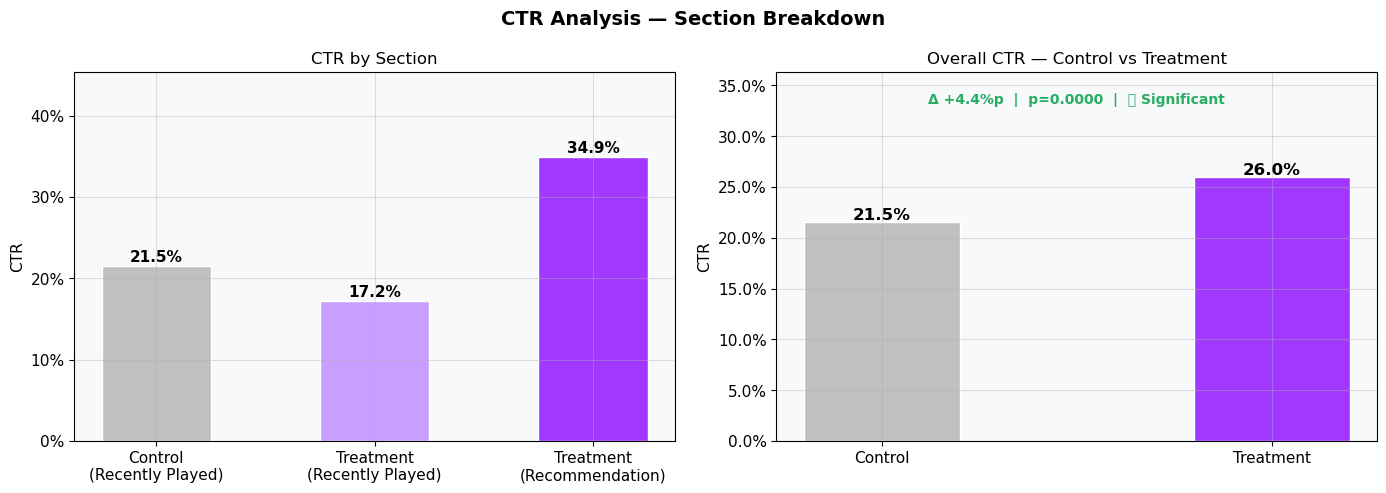

Saved -> ctr_analysis.png


In [71]:
# ── CTR Breakdown Visualization ────────────────────────────────────
# Show CTR by section: Control RP vs Treatment RP vs Treatment Rec

sections = ['Control\n(Recently Played)', 'Treatment\n(Recently Played)', 'Treatment\n(Recommendation)']
ctrs     = [
    df_discovery[(df_discovery.user_group=='control') & (df_discovery.section=='recently_played')]['ctr'].values[0],
    df_discovery[(df_discovery.user_group=='treatment') & (df_discovery.section=='recently_played')]['ctr'].values[0],
    df_discovery[(df_discovery.user_group=='treatment') & (df_discovery.section=='recommendation')]['ctr'].values[0],
]
colors_bar = ['#C0C0C0', '#C89EFF', '#A238FF']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CTR Analysis — Section Breakdown', fontsize=14, fontweight='bold')

# Left: CTR by section
ax1 = axes[0]
bars = ax1.bar(sections, ctrs, color=colors_bar, width=0.5, edgecolor='white')
ax1.set_title('CTR by Section', fontsize=12)
ax1.set_ylabel('CTR')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_ylim(0, max(ctrs) * 1.3)
for bar, val in zip(bars, ctrs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

# Right: Overall CTR comparison
ax2 = axes[1]
bars2 = ax2.bar(['Control', 'Treatment'], [p_ctrl_ctr, p_trt_ctr],
                color=['#C0C0C0', '#A238FF'], width=0.4, edgecolor='white')
ax2.set_title('Overall CTR — Control vs Treatment', fontsize=12)
ax2.set_ylabel('CTR')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.set_ylim(0, max(p_ctrl_ctr, p_trt_ctr) * 1.4)
for bar, val in zip(bars2, [p_ctrl_ctr, p_trt_ctr]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
ax2.text(0.5, max(p_ctrl_ctr, p_trt_ctr) * 1.28,
         f'Δ {diff_ctr:+.1%}p  |  p={p_val_ctr:.4f}  |  ✅ Significant',
         ha='center', fontsize=10, color='#27AE60', fontweight='bold',
         transform=ax2.transData)

plt.tight_layout()
plt.savefig('ctr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ctr_analysis.png')

## 6. Cannibalization & Net Click Growth (Deterioration + Guardrail Metrics)

**Cannibalization** measures how much the new recommendation section displaced consumption from the legacy Recently Played section.
Formula: `(plays_RP_control - plays_RP_treatment) / plays_RP_control`

**Net Click Growth** measures whether total plays increased despite the cannibalization.
Formula: `(total_plays_treatment - total_plays_control) / total_plays_control`

Following Spotify's industry standard, plays (consumption) are used instead of clicks (engagement proxy).

In [53]:
# ── Cannibalization & Net Click Growth ─────────────────────────────

ctrl_rp  = df_discovery[(df_discovery.user_group == 'control') &
                         (df_discovery.section == 'recently_played')]
trt_rp   = df_discovery[(df_discovery.user_group == 'treatment') &
                         (df_discovery.section == 'recently_played')]
trt_rec  = df_discovery[(df_discovery.user_group == 'treatment') &
                         (df_discovery.section == 'recommendation')]

ctrl_rp_plays  = ctrl_rp['total_plays'].values[0]
trt_rp_plays   = trt_rp['total_plays'].values[0]
trt_rec_plays  = trt_rec['total_plays'].values[0]
ctrl_all_plays = ctrl_rp_plays
trt_all_plays  = trt_rp_plays + trt_rec_plays

cannib     = (ctrl_rp_plays - trt_rp_plays) / ctrl_rp_plays
net_growth = (trt_all_plays - ctrl_all_plays) / ctrl_all_plays

print('── Cannibalization & Net Click Growth ──────────────────')
print(f'  Control RP plays    : {ctrl_rp_plays:,}')
print(f'  Treatment RP plays  : {trt_rp_plays:,}')
print(f'  Treatment Rec plays : {trt_rec_plays:,}')
print(f'  Treatment Total     : {trt_all_plays:,}')
print(f'\n  Cannibalization  : {cannib:.1%}  (drop in RP plays)')
print(f'  Net Click Growth : {net_growth:+.1%}  (change in total plays)')

print('\n  Interpretation:')
if cannib > 0.3:
    print(f'  ⚠️  Cannibalization {cannib:.1%} — high RP traffic displacement')
else:
    print(f'  ✅ Cannibalization {cannib:.1%} — within acceptable range')

if net_growth > 0:
    print(f'  ✅ Net Growth {net_growth:+.1%} — total consumption increased')
else:
    print(f'  ❌ Net Growth {net_growth:+.1%} — total consumption decreased')
print('─────────────────────────────────────────────────────────')

── Cannibalization & Net Click Growth ──────────────────
  Control RP plays    : 12,315
  Treatment RP plays  : 5,335
  Treatment Rec plays : 10,499
  Treatment Total     : 15,834

  Cannibalization  : 56.7%  (drop in RP plays)
  Net Click Growth : +28.6%  (change in total plays)

  Interpretation:
  ⚠️  Cannibalization 56.7% — high RP traffic displacement
  ✅ Net Growth +28.6% — total consumption increased
─────────────────────────────────────────────────────────


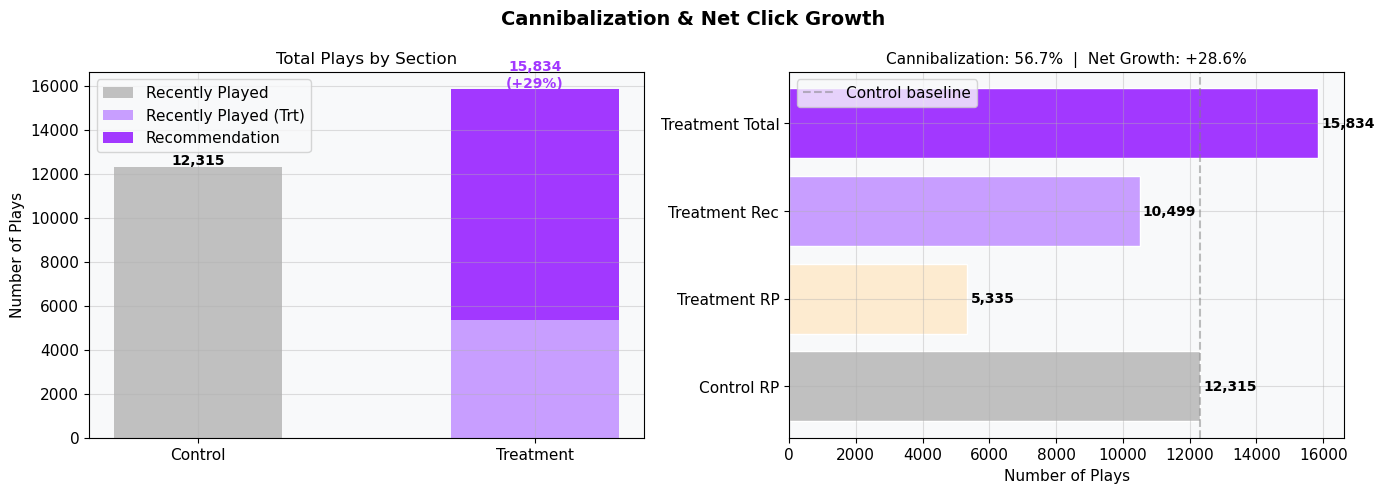

Saved -> cannibalization.png


In [76]:
# ── Cannibalization Visualization ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cannibalization & Net Click Growth', fontsize=14, fontweight='bold')

# Left: Stacked bar — plays breakdown
ax1 = axes[0]
x = np.arange(2)
ax1.bar([0], [ctrl_rp_plays], color='#C0C0C0', width=0.5, label='Recently Played')
ax1.bar([1], [trt_rp_plays],  color='#C89EFF', width=0.5, label='Recently Played (Trt)')
ax1.bar([1], [trt_rec_plays], color='#A238FF', width=0.5, label='Recommendation',
        bottom=[trt_rp_plays])

ax1.set_title('Total Plays by Section', fontsize=12)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Control', 'Treatment'])
ax1.set_ylabel('Number of Plays')
ax1.legend()

ax1.text(0, ctrl_rp_plays + 100, f'{ctrl_rp_plays:,}',
         ha='center', fontsize=10, fontweight='bold')
ax1.text(1, trt_all_plays + 100, f'{trt_all_plays:,}\n(+{net_growth:.0%})',
         ha='center', fontsize=10, fontweight='bold', color='#A238FF')

# Right: Cannibalization & Net Growth metrics
ax2 = axes[1]
categories = ['Control RP', 'Treatment RP', 'Treatment Rec', 'Treatment Total']
values     = [ctrl_rp_plays, trt_rp_plays, trt_rec_plays, trt_all_plays]
bar_colors = ['#C0C0C0', '#FDEBD0', '#C89EFF', '#A238FF']

bars = ax2.barh(categories, values, color=bar_colors, edgecolor='white')
ax2.set_title(f'Cannibalization: {cannib:.1%}  |  Net Growth: {net_growth:+.1%}', fontsize=11)
ax2.set_xlabel('Number of Plays')

for bar, val in zip(bars, values):
    ax2.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax2.axvline(x=ctrl_rp_plays, color='gray', linestyle='--', alpha=0.5, label='Control baseline')
ax2.legend()

plt.tight_layout()
plt.savefig('cannibalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> cannibalization.png')

## 7. Business Decision (Spotify Confidence Framework)

Benchmarked against Spotify's Confidence experimentation platform.
Metrics are classified into four categories to drive a structured launch decision.
This framework applies to any subscription-based streaming business including Deezer.

| Category | Definition | Our Metric |
|----------|------------|------------|
| **Success** | Metrics the feature aims to improve | D+30 Retention, Conversion Rate, CTR |
| **Guardrail** | Metrics that must not deteriorate | Net Click Growth (total consumption) |
| **Deterioration** | Side-effect detection | Cannibalization (RP traffic displacement) |
| **Quality** | Experiment integrity checks | SRM Check |

**Spotify's launch rule:**
> Treatment must be superior on at least one Success Metric,
> non-inferior on all Guardrail Metrics,
> and the change must make sense from a business perspective.

In [55]:
# ── Business Decision Summary ──────────────────────────────────────

print('══ Business Decision Summary ════════════════════════════')
print()
print('  [Quality Metrics]')
print(f'  SRM Check          : ✅ p={p_srm:.4f}  → No sample ratio mismatch')
print()
print('  [Success Metrics]')
print(f'  D+30 Retention     : ✅ {p_ctrl_ret:.1%} → {p_trt_ret:.1%}  ({diff_ret:+.1%}p, p={p_val_ret:.4f})')
print(f'  Conversion Rate    : ✅ {p_ctrl_conv:.1%} → {p_trt_conv:.1%}  ({diff_conv:+.1%}p, p={p_val_conv:.4f})')
print(f'  CTR (Overall)      : ✅ {p_ctrl_ctr:.1%} → {p_trt_ctr:.1%}  ({diff_ctr:+.1%}p, p={p_val_ctr:.4f})')
print()
print('  [Guardrail Metrics]')
print(f'  Net Click Growth   : ✅ {net_growth:+.1%}  → Total consumption increased')
print()
print('  [Deterioration Metrics]')
print(f'  Cannibalization    : ⚠️  {cannib:.1%}  → High RP traffic displacement')
print(f'                        Offset by Net Growth {net_growth:+.1%}')
print('═════════════════════════════════════════════════════════')
print()
print('  ✅ RECOMMENDATION: SHIP')
print()
print('  Rationale:')
print('  - All three Success Metrics improved with statistical significance')
print('  - Guardrail (Net Growth) is positive → no net consumption loss')
print(f'  - Cannibalization is high ({cannib:.0%}), but users are shifting to')
print('    recommendation — not leaving the platform')
print(f'  - D+30 retention uplift (+{diff_ret:.1%}p) is the strongest signal:')
print('    users who saw recommendations stayed longer')
print(f'  - Conversion uplift (+{diff_conv:.1%}p, +{relative_lift:.0%} relative) directly')
print('    drives subscription revenue')
print('═════════════════════════════════════════════════════════')

══ Business Decision Summary ════════════════════════════

  [Quality Metrics]
  SRM Check          : ✅ p=0.7882  → No sample ratio mismatch

  [Success Metrics]
  D+30 Retention     : ✅ 3.4% → 7.5%  (+4.1%p, p=0.0105)
  Conversion Rate    : ✅ 3.4% → 5.4%  (+2.0%p, p=0.0000)
  CTR (Overall)      : ✅ 21.5% → 26.0%  (+4.4%p, p=0.0000)

  [Guardrail Metrics]
  Net Click Growth   : ✅ +28.6%  → Total consumption increased

  [Deterioration Metrics]
  Cannibalization    : ⚠️  56.7%  → High RP traffic displacement
                        Offset by Net Growth +28.6%
═════════════════════════════════════════════════════════

  ✅ RECOMMENDATION: SHIP

  Rationale:
  - All three Success Metrics improved with statistical significance
  - Guardrail (Net Growth) is positive → no net consumption loss
  - Cannibalization is high (57%), but users are shifting to
    recommendation — not leaving the platform
  - D+30 retention uplift (+4.1%p) is the strongest signal:
    users who saw recommendations st

In [74]:
# ── Revenue Impact Estimate ────────────────────────────────────────
# LTV = ARPU x Gross Margin / Monthly Churn Rate
# Source: Deezer FY2024 IR (GM 25.9% → conservative 25%), MIDiA Research (churn 2%)

ARPU_BLENDED  = 9.59   # Blended ARPU (EUR): weighted avg of FR/DE/BR at 40/30/30
GROSS_MARGIN  = 0.25
MONTHLY_CHURN = 0.02

LTV = ARPU_BLENDED * GROSS_MARGIN / MONTHLY_CHURN

# Additional conversions driven by treatment
incremental_conv = trt_conv - ctrl_conv
incremental_ltv  = incremental_conv * LTV

# Scaling: if rolled out to 10M Deezer users (rough active user base)
scale_users       = 10_000_000
conv_rate_lift    = p_trt_conv - p_ctrl_conv
scaled_new_conv   = scale_users * conv_rate_lift
scaled_ltv_impact = scaled_new_conv * LTV

print('── Revenue Impact Estimate ─────────────────────────────')
print(f'  LTV (blended)        : €{LTV:,.2f}')
print(f'  ARPU (blended)       : €{ARPU_BLENDED}')
print(f'  Gross Margin         : {GROSS_MARGIN:.0%}')
print(f'  Monthly Churn        : {MONTHLY_CHURN:.0%}')
print()
print(f'  Incremental conversions (experiment) : +{incremental_conv:,}')
print(f'  Incremental LTV (experiment)         : +€{incremental_ltv:,.0f}')
print()
print(f'  If rolled out to {scale_users/1e6:.0f}M users:')
print(f'  Estimated new conversions : +{scaled_new_conv:,.0f}')
print(f'  Estimated LTV impact      : +€{scaled_ltv_impact/1e6:.1f}M')
print('─────────────────────────────────────────────────────────')

── Revenue Impact Estimate ─────────────────────────────
  LTV (blended)        : €119.88
  ARPU (blended)       : €9.59
  Gross Margin         : 25%
  Monthly Churn        : 2%

  Incremental conversions (experiment) : +198
  Incremental LTV (experiment)         : +€23,735

  If rolled out to 10M users:
  Estimated new conversions : +196,329
  Estimated LTV impact      : +€23.5M
─────────────────────────────────────────────────────────


In [77]:
# ── Business Decision Summary ──────────────────────────────────────

print('══ Business Decision Summary (Spotify Confidence Framework) ══════')
print()
print('  [Quality Metrics]')
print(f'  SRM Check          : PASS  p={p_srm:.4f}  → No sample ratio mismatch')
print()
print('  [Success Metrics]')
print(f'  D+30 Retention     : PASS  {p_ctrl_ret:.1%} → {p_trt_ret:.1%}  ({diff_ret:+.1%}p, p={p_val_ret:.4f})')
print(f'  Conversion Rate    : PASS  {p_ctrl_conv:.1%} → {p_trt_conv:.1%}  ({diff_conv:+.1%}p, +{relative_lift:.0%} relative, p={p_val_conv:.4f})')
print(f'  CTR (Overall)      : PASS  {p_ctrl_ctr:.1%} → {p_trt_ctr:.1%}  ({diff_ctr:+.1%}p, p={p_val_ctr:.4f})')
print()
print('  [Guardrail Metrics]')
print(f'  Net Click Growth   : PASS  {net_growth:+.1%}  → Total consumption increased despite cannibalization')
print()
print('  [Deterioration Metrics]')
print(f'  Cannibalization    : WARN  {cannib:.1%}  → High RP traffic displacement')
print(f'                       Offset by Net Growth {net_growth:+.1%} — users shifted to recommendation,')
print( '                       not away from the platform')
print()
print('══════════════════════════════════════════════════════════════════')
print()
print('  Rationale:')
print(f'  1. D+30 retention improved from {p_ctrl_ret:.1%} to {p_trt_ret:.1%} (+{diff_ret:.1%}p, p={p_val_ret:.4f})')
print( '     → Users who saw recommendations stayed longer. Primary OEC achieved.')
print()
print(f'  2. Conversion rate improved from {p_ctrl_conv:.1%} to {p_trt_conv:.1%} (+{relative_lift:.0%} relative uplift)')
print( '     → Recommendation engagement directly drove Free → Premium conversion.')

# Revenue impact
ARPU_BLENDED  = 9.59
GROSS_MARGIN  = 0.25
MONTHLY_CHURN = 0.02
LTV = ARPU_BLENDED * GROSS_MARGIN / MONTHLY_CHURN
incremental_conv    = trt_conv - ctrl_conv
scaled_ltv_impact   = 10_000_000 * (p_trt_conv - p_ctrl_conv) * LTV
print(f'     Estimated LTV impact at full rollout (10M users): +€{scaled_ltv_impact/1e6:.1f}M')
print()
print(f'  3. Cannibalization is high ({cannib:.0%}), but net plays increased {net_growth:+.1%}.')
print( '     → Recommendation replaced Recently Played, not total consumption.')
print()
print('══════════════════════════════════════════════════════════════════')
print()
print('  FINAL RECOMMENDATION: SHIP')
print()
print('  We recommend a full rollout of the context-aware recommendation')
print('  card feature. All three Success Metrics improved with statistical')
print('  significance. The Guardrail metric (Net Click Growth) remained')
print('  positive, and the high Cannibalization rate reflects a user')
print('  behavior shift — not platform disengagement. The feature drives')
print('  measurable retention and revenue uplift, meeting the bar for a')
print('  successful experiment under the Spotify Confidence framework.')
print()
print('══════════════════════════════════════════════════════════════════')

══ Business Decision Summary (Spotify Confidence Framework) ══════

  [Quality Metrics]
  SRM Check          : PASS  p=0.7882  → No sample ratio mismatch

  [Success Metrics]
  D+30 Retention     : PASS  3.4% → 7.5%  (+4.1%p, p=0.0105)
  Conversion Rate    : PASS  3.4% → 5.4%  (+2.0%p, +57% relative, p=0.0000)
  CTR (Overall)      : PASS  21.5% → 26.0%  (+4.4%p, p=0.0000)

  [Guardrail Metrics]
  Net Click Growth   : PASS  +28.6%  → Total consumption increased despite cannibalization

  [Deterioration Metrics]
  Cannibalization    : WARN  56.7%  → High RP traffic displacement
                       Offset by Net Growth +28.6% — users shifted to recommendation,
                       not away from the platform

══════════════════════════════════════════════════════════════════

  Rationale:
  1. D+30 retention improved from 3.4% to 7.5% (+4.1%p, p=0.0105)
     → Users who saw recommendations stayed longer. Primary OEC achieved.

  2. Conversion rate improved from 3.4% to 5.4% (+57% rela

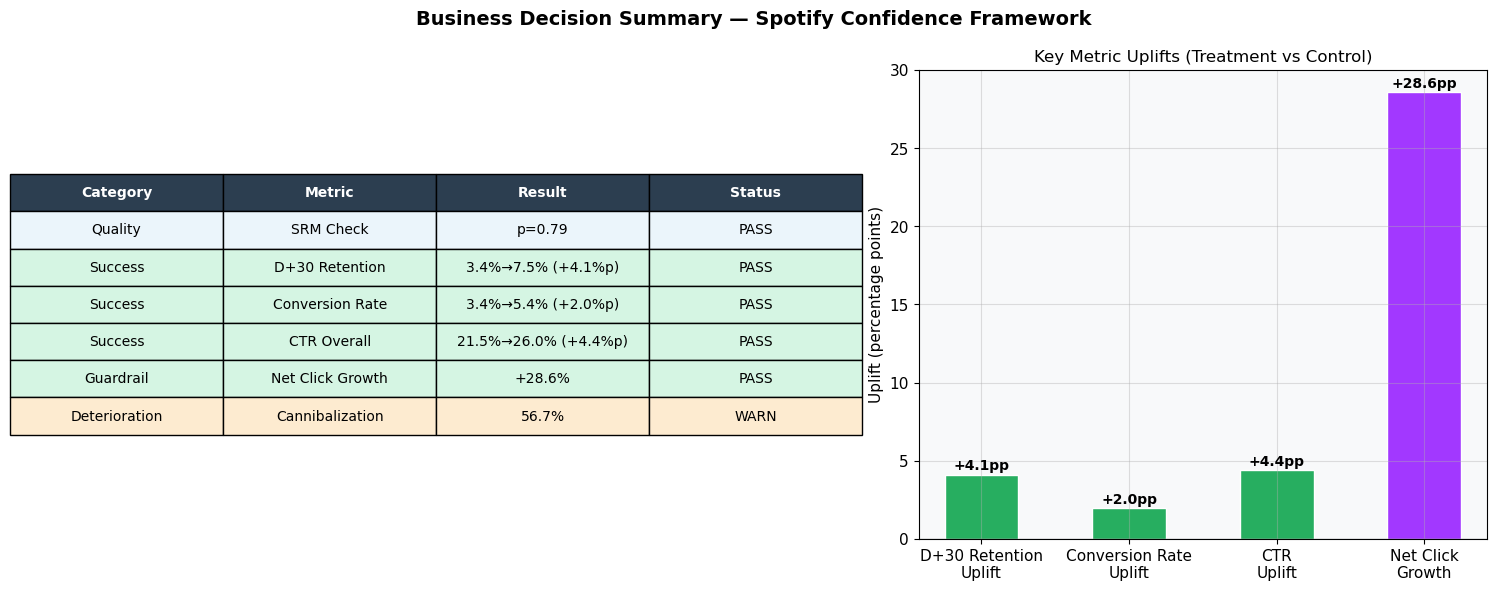

Saved -> business_decision.png


In [79]:
# ── Business Decision Summary Visualization ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Business Decision Summary — Spotify Confidence Framework', fontsize=14, fontweight='bold')

# Left: Metrics scorecard
ax1 = axes[0]
ax1.axis('off')

scorecard = [
    ['Category', 'Metric', 'Result', 'Status'],
    ['Quality',      'SRM Check',         f'p={p_srm:.2f}',              'PASS'],
    ['Success',      'D+30 Retention',    f'{p_ctrl_ret:.1%}→{p_trt_ret:.1%} ({diff_ret:+.1%}p)', 'PASS'],
    ['Success',      'Conversion Rate',   f'{p_ctrl_conv:.1%}→{p_trt_conv:.1%} ({diff_conv:+.1%}p)', 'PASS'],
    ['Success',      'CTR Overall',       f'{p_ctrl_ctr:.1%}→{p_trt_ctr:.1%} ({diff_ctr:+.1%}p)', 'PASS'],
    ['Guardrail',    'Net Click Growth',  f'{net_growth:+.1%}',          'PASS'],
    ['Deterioration','Cannibalization',   f'{cannib:.1%}',               'WARN'],
]

table = ax1.table(cellText=scorecard[1:], colLabels=scorecard[0],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 2.2)

header_color = '#2C3E50'
for j in range(4):
    table[0, j].set_facecolor(header_color)
    table[0, j].set_text_props(color='white', fontweight='bold')

row_colors = {'Quality': '#EBF5FB', 'Success': '#D5F5E3', 'Guardrail': '#D5F5E3', 'Deterioration': '#FDEBD0'}
for i, row in enumerate(scorecard[1:]):
    color = row_colors.get(row[0], 'white')
    for j in range(4):
        table[i+1, j].set_facecolor(color)

# Right: Key metrics bar
ax2 = axes[1]
metrics      = ['D+30 Retention\nUplift', 'Conversion Rate\nUplift', 'CTR\nUplift', 'Net Click\nGrowth']
uplifts      = [diff_ret * 100, diff_conv * 100, diff_ctr * 100, net_growth * 100]
bar_colors2  = ['#27AE60', '#27AE60', '#27AE60', '#A238FF']

bars = ax2.bar(metrics, uplifts, color=bar_colors2, width=0.5, edgecolor='white')
ax2.set_title('Key Metric Uplifts (Treatment vs Control)', fontsize=12)
ax2.set_ylabel('Uplift (percentage points)')
ax2.axhline(y=0, color='black', linewidth=0.8)

for bar, val in zip(bars, uplifts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'+{val:.1f}pp', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('business_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> business_decision.png')

## 8. Post-Launch Monitoring & Next Steps

**Metrics to monitor after full rollout:**
- D+30 retention trend (weekly cohort tracking in Tableau)
- Cannibalization stabilization — does RP displacement plateau?
- Conversion rate by country (FR / DE / BR may respond differently)
- Recommendation CTR decay — novelty effect typically fades after 2-4 weeks

**Next experiments to consider:**
1. **Personalization depth** — test stronger vs weaker personalization signals
2. **Card position** — recommendation above vs below Recently Played
3. **Country-specific tuning** — event-based cards performed well in BR (Carnival); test local content expansion
4. **Freemium paywall** — test whether showing premium-only recommendations increases conversion further